# 01 - Minimum aerodynamic database and steady level flight

Every performance calculation needs a small "aerodynamic database":

1. the **drag polar** $C_D(C_L)$ in each configuration (clean, take-off, landing);
2. the **maximum lift coefficient** $C_{L_{max}}$ of each configuration;
3. from these: the **characteristic points** of the polar and the
   **characteristic speeds** (stall, minimum drag, minimum power, maximum speed).

References: Roskam & Lan, Chapter 5 (drag polars, Sec. 5.4 simplified method),
Chapter 8 (steady flight, Sec. 8.4 level flight), Sec. 12.3 (maximum speeds).

In [1]:
# --- Setup -------------------------------------------------------------------
# The notebooks live in PrestazioniRoskam/, one level below the repository root,
# where the `aircraft_performance` package is. Make it importable:
import sys
import pathlib
ROOT = pathlib.Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

import aircraft_performance as ap
from aircraft_performance import units as u
from aircraft_performance.atmosphere import isa
from aircraft_performance.plotting import apply_style, reference_line
from aircraft_performance.reporting import print_table

apply_style()
print(f"aircraft_performance v{ap.__version__} ready")

from aircraft_performance import aerodynamics as aero, level_flight as lf

single = ap.examples.light_single_piston()
jet = ap.examples.business_jet_giv()

aircraft_performance v1.0.0 ready


## 1. The parabolic drag polar

For subsonic, attached flow the drag polar is well approximated by
(Roskam Eqn 5.37):

$$
C_D = C_{D_0} + K\,C_L^2, \qquad K = \frac{1}{\pi\,A\,e}
$$

* $C_{D_0}$ - zero-lift (parasite) drag coefficient: skin friction, form and
  interference drag of the whole aircraft;
* $K\,C_L^2$ - drag due to lift, with $A = b^2/S$ the aspect ratio and $e$
  the Oswald factor ($0.7 \div 0.9$ for real aircraft, Roskam Table 5.4).

### Estimating $C_{D_0}$: the equivalent parasite area (Roskam Sec. 5.4)

In preliminary design $C_{D_0}$ is obtained from the **equivalent parasite
area** $f$, i.e. the area of a flat plate with $C_D = 1$ having the same drag:

$$
C_{D_0} = \frac{f}{S}, \qquad f = C_f\,S_{wet}
$$

where $S_{wet}$ is the total wetted area and $C_f$ an equivalent skin-friction
coefficient read from Roskam Figs. 5.41-5.43, which depends on the "cleanness"
of the design.

In [2]:
print_table(["aircraft class", "C_f"],
            [[k, v] for k, v in aero.TYPICAL_SKIN_FRICTION_COEFFICIENTS.items()], ["{}", "{:.4f}"])

# Example: light single, wetted area ~ 4 x wing area
S = single.wing_area
S_wet = 4.0 * S
for cf in (0.0060, 0.0075, 0.0090):
    f = aero.equivalent_parasite_area(S_wet, cf)
    print(f"C_f = {cf:.4f}:  f = {f:.3f} m^2  ->  CD0 = {aero.cd0_from_parasite_area(f, S):.4f}")

                           aircraft class     C_f
-----------------------------------------  ------
                            jet transport  0.0030
                             business jet  0.0040
                              jet fighter  0.0040
       turboprop / multi-engine propeller  0.0045
single-engine propeller, retractable gear  0.0060
      single-engine propeller, fixed gear  0.0090
                                sailplane  0.0030
C_f = 0.0060:  f = 0.384 m^2  ->  CD0 = 0.0240
C_f = 0.0075:  f = 0.480 m^2  ->  CD0 = 0.0300
C_f = 0.0090:  f = 0.576 m^2  ->  CD0 = 0.0360


A value between the retractable-gear and fixed-gear lines ($C_f \approx 0.0075$)
gives $C_{D_0}\approx 0.030$, the value used in the `Capitolo9` exercises for
this aircraft.

### Oswald factor

If no data are available $e$ can be estimated with an empirical correlation
(`aero.oswald_factor_estimate`, Raymer's formula - *not* from Roskam, use it
only as a first guess).

In [3]:
for AR in (6.0, 7.56, 9.0, 12.0):
    print(f"AR = {AR:5.2f}  ->  e = {aero.oswald_factor_estimate(AR):.3f}")

AR =  6.00  ->  e = 0.869
AR =  7.56  ->  e = 0.823
AR =  9.00  ->  e = 0.783
AR = 12.00  ->  e = 0.706


### Configurations: flaps and landing gear

Flaps and landing gear mainly add parasite drag, $\Delta C_{D_0}$, and raise
$C_{L_{max}}$ (Roskam Sec. 5.1.2, Fig. 9.11, Table 8.2). Each example aircraft
therefore carries three configurations.

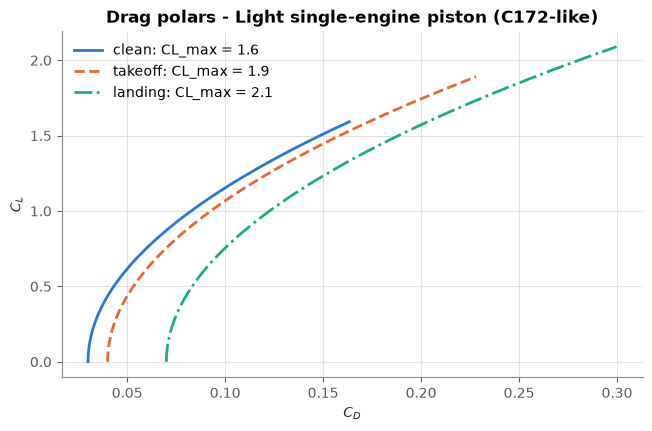

configuration     CD0       K  CL_max  E_max
-------------  ------  ------  ------  -----
        clean  0.0300  0.0526    1.60  12.59
      takeoff  0.0400  0.0526    1.90  10.90
      landing  0.0700  0.0526    2.10   8.24


In [4]:
CL = np.linspace(0.0, 2.2, 200)
fig, ax = plt.subplots()
for name, conf in single.configurations.items():
    mask = CL <= conf.CL_max
    ax.plot(conf.polar.drag_coefficient(CL[mask]), CL[mask], label=f"{name}: CL_max = {conf.CL_max}")
ax.set_xlabel("$C_D$")
ax.set_ylabel("$C_L$")
ax.set_title(f"Drag polars - {single.name}")
ax.legend()
plt.show()

print_table(["configuration", "CD0", "K", "CL_max", "E_max"],
            [[n, c.polar.CD0, c.polar.K, c.CL_max, c.polar.max_lift_to_drag] for n, c in single.configurations.items()],
            ["{}", "{:.4f}", "{:.4f}", "{:.2f}", "{:.2f}"])

## 2. Characteristic points of the polar

The ratios $C_L/C_D$, $C_L^{3/2}/C_D$ and $C_L^{1/2}/C_D$ govern, respectively,
minimum drag, minimum power and jet range. Setting their derivative with
respect to $C_L$ to zero gives (Roskam Eqns 8.18-8.19, 8.25-8.26, 11.65-11.66):

| Point | Maximises | $C_L$ | $C_D$ | Meaning |
|---|---|---|---|---|
| **E** | $C_L/C_D$ | $\sqrt{C_{D_0}/K}$ | $2C_{D_0}$ | minimum drag; best glide; prop range; jet endurance |
| **P** | $C_L^{3/2}/C_D$ | $\sqrt{3C_{D_0}/K}$ | $4C_{D_0}$ | minimum power; minimum sink; prop endurance and best RC |
| **A** | $C_L^{1/2}/C_D$ | $\sqrt{C_{D_0}/(3K)}$ | $\tfrac43 C_{D_0}$ | jet range at constant altitude |

with $E_{max} = 1/(2\sqrt{C_{D_0}K})$. At point E induced and parasite drag are
equal; at point P the induced drag is three times the parasite drag.

point      CL      CD  CL/CD  CL^1.5/CD  CL^0.5/CD
-----  ------  ------  -----  ---------  ---------
    A  0.2500  0.0200  12.50       6.25      25.00
    E  0.4330  0.0300  14.43       9.50      21.93
    P  0.7500  0.0600  12.50      10.83      14.43


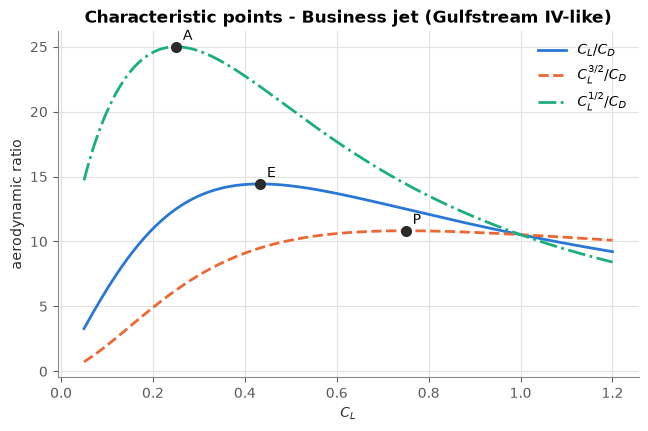

In [5]:
pol = jet.polar()
pts = pol.characteristic_points()
print_table(["point", "CL", "CD", "CL/CD", "CL^1.5/CD", "CL^0.5/CD"],
            [[p.name, p.CL, p.CD, p.lift_to_drag, p.endurance_parameter, p.range_parameter_jet] for p in pts.values()],
            ["{}", "{:.4f}", "{:.4f}", "{:.2f}", "{:.2f}", "{:.2f}"])

CL = np.linspace(0.05, 1.2, 300)
CD = pol.drag_coefficient(CL)
fig, ax = plt.subplots()
for ratio, label in [(CL / CD, "$C_L/C_D$"), (CL**1.5 / CD, "$C_L^{3/2}/C_D$"), (CL**0.5 / CD, "$C_L^{1/2}/C_D$")]:
    ax.plot(CL, ratio, label=label)
for p, y in [(pts["E"], pts["E"].lift_to_drag), (pts["P"], pts["P"].endurance_parameter), (pts["A"], pts["A"].range_parameter_jet)]:
    ax.plot(p.CL, y, "o", color="#2b2b28")
    ax.annotate(p.name, (p.CL, y), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("$C_L$")
ax.set_ylabel("aerodynamic ratio")
ax.set_title(f"Characteristic points - {jet.name}")
ax.legend()
plt.show()

**Check against Anderson Example 5.4** (Gulfstream IV, $C_{D_0}=0.015$,
$K=0.08$): $(L/D)_{max} = 14.43$, $(C_L^{1/2}/C_D)_{max}=25.0$. At 30,000 ft the
three speeds are in the ratio $V_P : V_E : V_A = 0.76 : 1 : 1.32$ (Roskam Eqn 8.75).

In [6]:
W, S = jet.weight, jet.wing_area
rho30 = isa(30000 * u.FT).density
V = {k: aero.speed_at_polar_point(W, S, rho30, p) for k, p in pts.items()}
print_table(["point", "V [m/s]", "V [ft/s]", "Anderson [ft/s]", "V / V_E"],
            [[k, V[k], V[k] / u.FT, ref, V[k] / V["E"]] for k, ref in (("P", 479.6), ("E", 631.2), ("A", 830.8))],
            ["{}", "{:.1f}", "{:.1f}", "{:.1f}", "{:.3f}"])

point  V [m/s]  V [ft/s]  Anderson [ft/s]  V / V_E
-----  -------  --------  ---------------  -------
    P    146.3     480.0            479.6    0.760
    E    192.6     631.8            631.2    1.000
    A    253.4     831.4            830.8    1.316


The 0.1 % differences come from the atmosphere: Anderson's tables use the
geometric altitude, this package the geopotential altitude (see
`atmosphere.geopotential_altitude`).

## 3. Speed, lift coefficient and stall speed

In level flight $L = W$, hence (Roskam Eqns 8.23, 8.32):

$$
V = \sqrt{\frac{2W}{\rho S C_L}}, \qquad V_S = \sqrt{\frac{2W}{\rho S C_{L_{max}}}}
$$

The stall speed grows with $\sqrt{W/S}$ and with $1/\sqrt{\sigma}$: at
constant *equivalent* airspeed ($V_E = V\sqrt{\sigma}$) it does not change with
altitude, which is why pilots use indicated speeds.

In [7]:
h = np.array([0.0, 1000.0, 2000.0, 3000.0, 4000.0])
rows = []
for hi in h:
    rho = isa(hi).density
    row = [hi]
    for conf_name in ("clean", "takeoff", "landing"):
        conf = single.config(conf_name)
        row.append(aero.stall_speed(single.weight, single.wing_area, rho, conf.CL_max) / u.KT)
    row.append(ap.atmosphere.true_to_equivalent_airspeed(
        aero.stall_speed(single.weight, single.wing_area, rho, single.config().CL_max), hi) / u.KT)
    rows.append(row)
print(f"Stall speeds of the {single.name} [kt TAS]")
print_table(["h [m]", "clean", "takeoff", "landing", "clean (EAS)"], rows,
            ["{:.0f}", "{:.1f}", "{:.1f}", "{:.1f}", "{:.1f}"])

Stall speeds of the Light single-engine piston (C172-like) [kt TAS]
h [m]  clean  takeoff  landing  clean (EAS)
-----  -----  -------  -------  -----------
    0   51.0     46.8     44.5         51.0
 1000   53.5     49.1     46.7         51.0
 2000   56.2     51.6     49.1         51.0
 3000   59.2     54.3     51.7         51.0
 4000   62.4     57.2     54.4         51.0


## 4. Thrust and power required

With a parabolic polar the drag in level flight splits into a parasite part
growing with $V^2$ and an induced part decreasing with $1/V^2$ (Roskam Eqns
8.59-8.61, 8.69-8.70):

$$
T_{req} = D = \underbrace{\tfrac12\rho V^2 S C_{D_0}}_{D_0} + \underbrace{\frac{K W^2}{\tfrac12\rho V^2 S}}_{D_i},
\qquad P_{req} = D\,V
$$

* minimum drag $D_{min} = W/E_{max}$ at point E, where $D_0 = D_i$ (Eqns 8.64-8.68);
* minimum power at point P, $V_{P} = 3^{-1/4}V_E \approx 0.76\,V_E$ (Eqn 8.75);
* $P_{req}$ at point E is 14 % higher than the minimum power (Eqn 8.77).

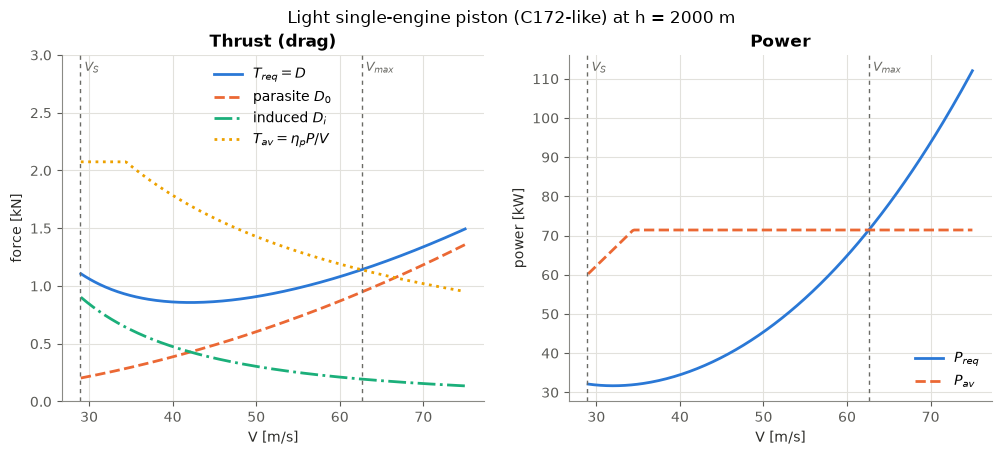

              speed  V [m/s]  V [kt]
-------------------  -------  ------
          stall V_S     28.9    56.2
      min power (P)     32.0    62.2
       min drag (E)     42.1    81.9
maximum level V_max     62.6   121.7

V_E / V_P = 1.316  (theory: 3^0.25 = 1.316)


In [8]:
h = 2000.0
V = np.linspace(20.0, 75.0, 300)
c = lf.performance_curves(single, h, V)
ok = ~c["below_stall"]          # we plot only speeds above the stall speed

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(V[ok], c["T_req"][ok] / 1000, label="$T_{req} = D$")
ax1.plot(V[ok], c["D0"][ok] / 1000, label="parasite $D_0$")
ax1.plot(V[ok], c["Di"][ok] / 1000, label="induced $D_i$")
ax1.plot(V[ok], c["T_av"][ok] / 1000, label="$T_{av} = \\eta_p P / V$")
ax1.set_xlabel("V [m/s]"); ax1.set_ylabel("force [kN]"); ax1.set_title("Thrust (drag)")
ax1.set_ylim(0, 3); ax1.legend()

ax2.plot(V[ok], c["P_req"][ok] / 1000, label="$P_{req}$")
ax2.plot(V[ok], c["P_av"][ok] / 1000, label="$P_{av}$")
ax2.set_xlabel("V [m/s]"); ax2.set_ylabel("power [kW]"); ax2.set_title("Power")
ax2.legend()
speeds = lf.level_flight_speeds(single, h)
for ax in (ax1, ax2):
    reference_line(ax, speeds.V_stall, label="$V_S$")
    reference_line(ax, speeds.V_max, label="$V_{max}$")
fig.suptitle(f"{single.name} at h = {h:.0f} m")
plt.show()

print_table(["speed", "V [m/s]", "V [kt]"],
            [["stall V_S", speeds.V_stall, speeds.V_stall / u.KT],
             ["min power (P)", speeds.V_min_power, speeds.V_min_power / u.KT],
             ["min drag (E)", speeds.V_min_drag, speeds.V_min_drag / u.KT],
             ["maximum level V_max", speeds.V_max, speeds.V_max / u.KT]],
            ["{}", "{:.1f}", "{:.1f}"])
print(f"\nV_E / V_P = {speeds.V_min_drag / speeds.V_min_power:.3f}  (theory: 3^0.25 = {3**0.25:.3f})")

Remarks:

* for this aircraft the minimum-power speed is only ~10 % above the stall speed
  ($C_{L_P} = 1.31$ versus $C_{L_{max}} = 1.6$): the low-speed branch of the
  curves is limited by the stall, not by the engine;
* the available power is flat ($\eta_p P$ constant, Roskam Sec. 9.3) except at
  the lowest speeds, where the propeller thrust $\eta_p P/V$ would exceed the
  **static thrust** of the propeller: the model caps it there (horizontal
  segment of $T_{av}$, sloping segment of $P_{av}$). Without the cap the thrust
  would diverge for $V \to 0$, which is unphysical and would break take-off
  calculations.

## 5. Maximum (and minimum) level speed

$V_{max}$ is the high-speed intersection of available and required curves.

**Jet, constant thrust, parabolic polar** - closed form (Roskam Eqn 12.14,
Anderson Eqn 5.50):

$$
V_{max}^2 = \frac{\left(\frac{T}{W}\right)\frac{W}{S} + \frac{W}{S}\sqrt{\left(\frac{T}{W}\right)^2 - 4C_{D_0}K}}{\rho\,C_{D_0}}
$$

If $T/W < 2\sqrt{C_{D_0}K} = 1/E_{max}$ no solution exists: the aircraft cannot
fly level (it is above its ceiling). The minus sign gives the low-speed
solution, to be compared with the stall speed.

**General case** (propeller, any lapse law): the intersection is found
numerically by `level_flight_speeds`, which also checks the result against the
stall speed and the drag-divergence Mach number.

In [9]:
rows = []
for h_ft in (0, 10000, 20000, 30000, 40000):
    h = h_ft * u.FT
    T = jet.propulsion.thrust_available(0.0, h)
    V_cf = lf.max_level_speed_jet_parabolic(jet.weight, jet.wing_area, isa(h).density, jet.polar(), T)
    V_num = lf.level_flight_speeds(jet, h).V_max
    rows.append([h_ft, T / 1000, V_cf, V_num, V_num / isa(h).speed_of_sound])
print_table(["h [ft]", "T_av [kN]", "V_max closed form", "V_max numerical", "Mach"], rows,
            ["{:.0f}", "{:.1f}", "{:.1f}", "{:.1f}", "{:.3f}"])

/tmp/ipykernel_4619/3476621939.py:6: PerformanceWarning: Maximum level speed: Mach number 1.141 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  V_num = lf.level_flight_speeds(jet, h).V_max
/tmp/ipykernel_4619/3476621939.py:6: PerformanceWarning: Maximum level speed: Mach number 1.254 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  V_num = lf.level_flight_speeds(jet, h).V_max
/tmp/ipykernel_4619/3476621939.py:6: PerformanceWarning: Maximum level speed: Mach number 1.386 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  V_num = lf.level_flight_speeds(jet, h).V_max


h [ft]  T_av [kN]  V_max closed form  V_max numerical   Mach
------  ---------  -----------------  ---------------  -----
     0      123.2              388.2            388.2  1.141
 10000      102.7              411.7            411.7  1.254
 20000       84.5              438.1            438.1  1.386
 30000       68.3              467.9            467.9  1.543
 40000       53.1              503.7            503.7  1.707


/tmp/ipykernel_4619/3476621939.py:6: PerformanceWarning: Maximum level speed: Mach number 1.543 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  V_num = lf.level_flight_speeds(jet, h).V_max
/tmp/ipykernel_4619/3476621939.py:6: PerformanceWarning: Maximum level speed: Mach number 1.707 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  V_num = lf.level_flight_speeds(jet, h).V_max


The closed form and the numerical solution coincide. However, the Mach numbers
are well beyond the drag-divergence Mach number ($M_{DD}\approx 0.85$) - which is
why a `PerformanceWarning` was printed. As Anderson points out in Example 5.6,
the parabolic polar ignores the transonic drag rise, so these "maximum speeds"
are not realistic: the real aircraft is limited to $M_{MO}\approx0.88$. The
warning is the package's way to prevent a silent misuse of the model.

## 6. The level-flight envelope

Repeating the calculation at increasing altitude gives the level-flight
envelope. The envelope closes at the **absolute ceiling**, where the available and required
curves become tangent and $V_{min}=V_{max}$ (Roskam Fig. 12.11); when the
minimum speed is stall-limited, as for these two aircraft, the two branches
approach each other only in the last few hundred metres below the ceiling. The function stops at the first infeasible altitude
instead of filling the arrays with `NaN`.

Light single-engine piston (C172-like): level flight impossible from h = 6500.0 m


Regional turboprop (ATR 72-like): level flight impossible from h = 8250.0 m


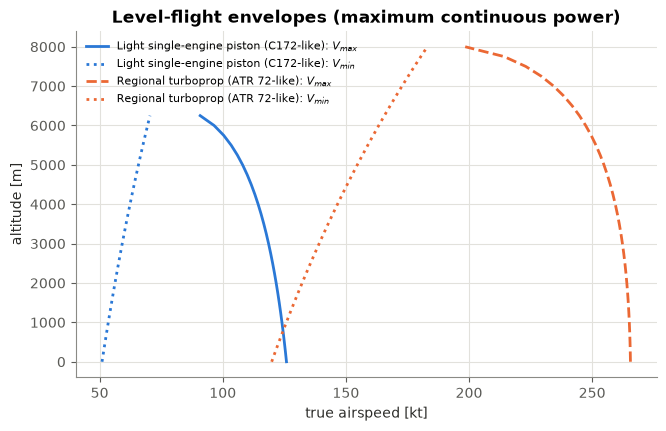

In [10]:
fig, ax = plt.subplots()
for aircraft in (single, ap.examples.regional_turboprop()):
    env = lf.flight_envelope(aircraft, np.arange(0.0, 12001.0, 250.0))
    l, = ax.plot(env["V_max"] / u.KT, env["altitude"], label=f"{aircraft.name}: $V_{{max}}$")
    ax.plot(env["V_min"] / u.KT, env["altitude"], color=l.get_color(), linestyle=":", label=f"{aircraft.name}: $V_{{min}}$")
    print(f"{aircraft.name}: level flight impossible from h = {env['first_infeasible_altitude']} m")
ax.set_xlabel("true airspeed [kt]")
ax.set_ylabel("altitude [m]")
ax.set_title("Level-flight envelopes (maximum continuous power)")
ax.legend(fontsize=8)
plt.show()

## 7. Exercises

1. Using `single.replace(...)`, add 100 kg of payload and recompute the table
   of characteristic speeds at 2,000 m. Which speeds scale with $\sqrt{W}$?
2. Change the Oswald factor of the clean polar from 0.8 to 0.7: how much do
   $E_{max}$ and $V_{max}$ change?
3. For the business jet, find (analytically and numerically) the altitude at
   which $T_{av}/W = 1/E_{max}$ - the absolute ceiling of level flight.